## Useful Visualizations

Working directory: /Users/danielpark/git/youtube-trailer-sentiment-imdb
Connected!
df1 shape: (796, 3)
df2 shape: (1586, 2)
df3 shape: (768, 5)


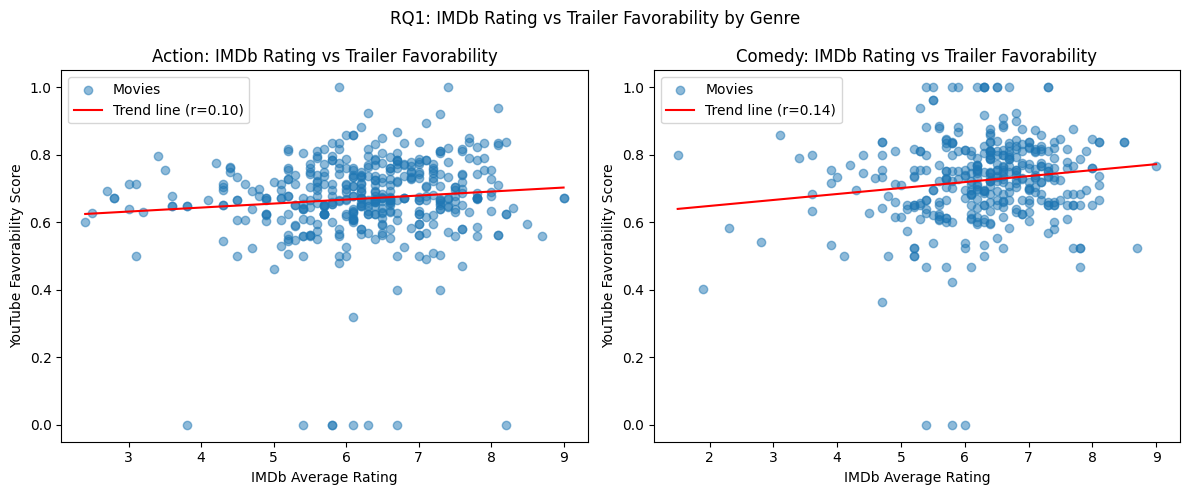

RQ1 plot saved.

RQ1 Interpretation:
The scatter plot shows the correlation between the IMDb ratings and YouTube trailer
favorability for Action and Comedy movies. Both movies depict a weak positive trend
(Action movies, r = 0.10; Comedy movies, r = 0.14), indicating that movies with
higher ratings on IMDb tend to have more favorable trailers. Comedy movies depict a
stronger correlation compared to Action movies. This might indicate that audience
response to Comedy movies is more uniform on both platforms.



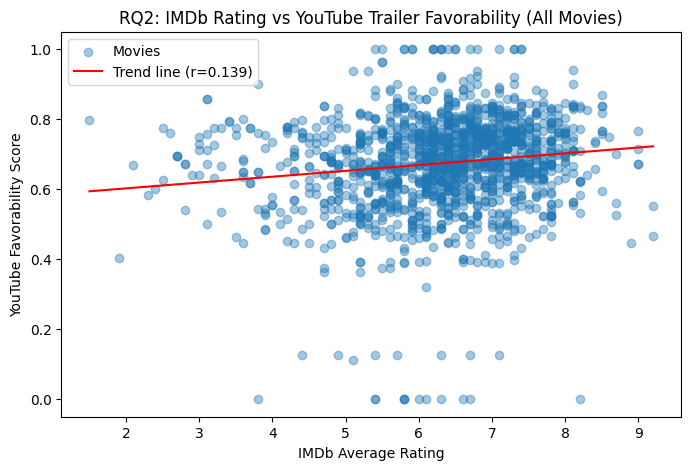

RQ2: r=0.1393, p=0.0000

RQ2 Interpretation:
The scatter plot illustrates the general trend of the IMDb ratings and YouTube trailer
favorability for all the movies. The linear regression gives us an r of 0.139,
which is statistically significant and shows a weak positive correlation. This tells us
that there is a general trend of higher IMDb rated movies having more favorable
trailers, but it is not a strong predictor of YouTube trailer favorability based solely
on the IMDb ratings.



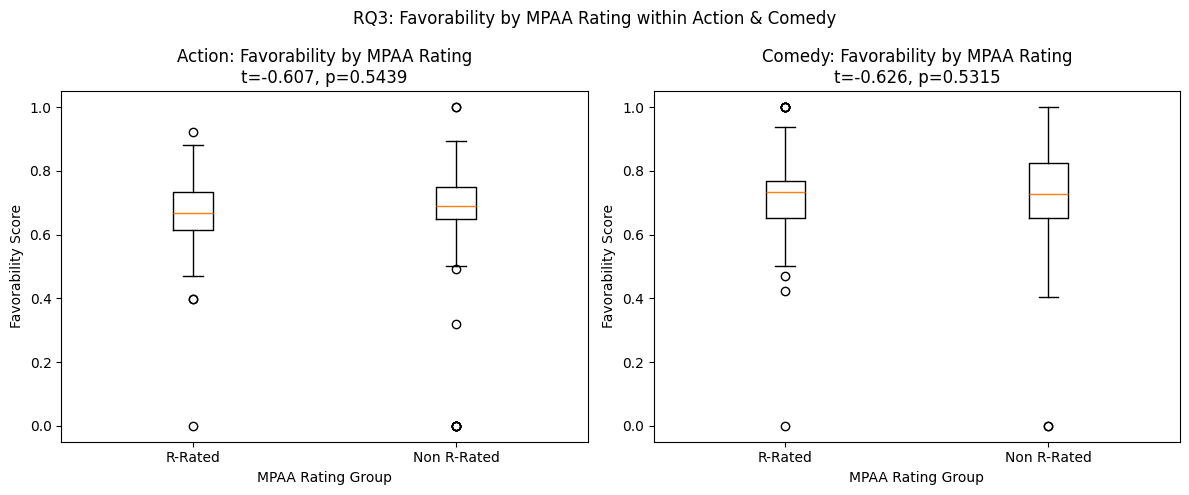

RQ3 plot saved.

RQ3 Interpretation:
The box plots compare the favorability of the YouTube trailer for the R-Rated and Non-R-Rated movies under the Action and Comedy genres. In both genres, the difference is found to be not statistically significant, as the value of the test statistic is -0.607 with a p-value of 0.54 for the Action genre, and -0.626 with a p-value of 0.53 for the Comedy genre. Therefore, it is found that the rating does not impact the favorability of the movie trailer on YouTube.



In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os
from pathlib import Path
#hello im eddy

# STEP 1: CONNECT TO SQLITE
# Find project root by looking for movies.db
project_root = Path.cwd()
while not (project_root / "data" / "database" / "movies.db").exists():
    project_root = project_root.parent

os.chdir(project_root)
print("Working directory:", os.getcwd())

connection = sqlite3.connect("data/database/movies.db")
print("Connected!")

# STEP 2: FETCH DATA
# Q1
df1 = pd.read_sql_query("""
    SELECT ms.genre, ms.favorability, r.averageRating
    FROM movies m
    JOIN ratings r ON m.tconst = r.tconst
    JOIN movie_sentiments ms ON m.primaryTitle_norm = ms.name_norm
    WHERE ms.genre IN ('Action', 'Comedy')
""", connection)

# Q2
df2 = pd.read_sql_query("""
    SELECT ms.favorability, r.averageRating
    FROM movies m
    JOIN ratings r ON m.tconst = r.tconst
    JOIN movie_sentiments ms ON m.primaryTitle_norm = ms.name_norm
    ORDER BY r.averageRating
""", connection)

# Q3
df3 = pd.read_sql_query("""
    SELECT 
        ms.genre,
        ms.rating,
        CASE 
            WHEN ms.rating = 'R' THEN 'R-Rated'
            ELSE 'Non R-Rated'
        END AS rating_group,
        ms.favorability,
        r.averageRating
    FROM movies m
    JOIN ratings r ON m.tconst = r.tconst
    JOIN movie_sentiments ms ON m.primaryTitle_norm = ms.name_norm
    WHERE ms.genre IN ('Action', 'Comedy')
    AND ms.rating IN ('R', 'PG', 'PG-13', 'G')
    ORDER BY ms.genre, rating_group
""", connection)

connection.close()

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("df3 shape:", df3.shape)

os.makedirs('results', exist_ok=True)

# RQ1 VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, genre in zip(axes, ['Action', 'Comedy']):
    subset = df1[df1['genre'] == genre]
    m, b, r_val, p_val, _ = stats.linregress(subset['averageRating'], subset['favorability'])
    x = np.linspace(subset['averageRating'].min(), subset['averageRating'].max(), 100)
    ax.scatter(subset['averageRating'], subset['favorability'], alpha=0.5, label='Movies')
    ax.plot(x, m*x + b, color='red', label=f'Trend line (r={r_val:.2f})')
    ax.set_title(f'{genre}: IMDb Rating vs Trailer Favorability')
    ax.set_xlabel('IMDb Average Rating')
    ax.set_ylabel('YouTube Favorability Score')
    ax.legend()

plt.suptitle('RQ1: IMDb Rating vs Trailer Favorability by Genre')
plt.tight_layout()
plt.savefig('results/rq1_scatter.png')
plt.show()
print("RQ1 plot saved.")
print("""
RQ1 Interpretation:
The scatter plot shows the correlation between the IMDb ratings and YouTube trailer
favorability for Action and Comedy movies. Both movies depict a weak positive trend
(Action movies, r = 0.10; Comedy movies, r = 0.14), indicating that movies with
higher ratings on IMDb tend to have more favorable trailers. Comedy movies depict a
stronger correlation compared to Action movies. This might indicate that audience
response to Comedy movies is more uniform on both platforms.
""")

# RQ2 VISUALIZATION
m, b, r_val, p_val, _ = stats.linregress(df2['averageRating'], df2['favorability'])
x = np.linspace(df2['averageRating'].min(), df2['averageRating'].max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(df2['averageRating'], df2['favorability'], alpha=0.4, label='Movies')
plt.plot(x, m*x + b, color='red', label=f'Trend line (r={r_val:.3f})')
plt.title('RQ2: IMDb Rating vs YouTube Trailer Favorability (All Movies)')
plt.xlabel('IMDb Average Rating')
plt.ylabel('YouTube Favorability Score')
plt.legend()
plt.savefig('results/rq2_linreg.png')
plt.show()
print(f"RQ2: r={r_val:.4f}, p={p_val:.4f}")
print("""
RQ2 Interpretation:
The scatter plot illustrates the general trend of the IMDb ratings and YouTube trailer
favorability for all the movies. The linear regression gives us an r of 0.139,
which is statistically significant and shows a weak positive correlation. This tells us
that there is a general trend of higher IMDb rated movies having more favorable
trailers, but it is not a strong predictor of YouTube trailer favorability based solely
on the IMDb ratings.
""")

# RQ3 VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, genre in zip(axes, ['Action', 'Comedy']):
    subset = df3[df3['genre'] == genre]
    r_group = subset[subset['rating_group'] == 'R-Rated']['favorability']
    non_r_group = subset[subset['rating_group'] == 'Non R-Rated']['favorability']
    t_stat, p_val = stats.ttest_ind(r_group, non_r_group, equal_var=False)

    ax.boxplot([r_group, non_r_group], tick_labels=['R-Rated', 'Non R-Rated'])
    ax.set_title(f'{genre}: Favorability by MPAA Rating\nt={t_stat:.3f}, p={p_val:.4f}')
    ax.set_ylabel('Favorability Score')
    ax.set_xlabel('MPAA Rating Group')

plt.suptitle('RQ3: Favorability by MPAA Rating within Action & Comedy')
plt.tight_layout()
plt.savefig('results/rq3_boxplot.png')
plt.show()
print("RQ3 plot saved.")
print("""
RQ3 Interpretation:
The box plots compare the favorability of the YouTube trailer for the R-Rated and Non-R-Rated movies under the Action and Comedy genres. In both genres, the difference is found to be not statistically significant, as the value of the test statistic is -0.607 with a p-value of 0.54 for the Action genre, and -0.626 with a p-value of 0.53 for the Comedy genre. Therefore, it is found that the rating does not impact the favorability of the movie trailer on YouTube.
""")